In [68]:
# =========================
# 1. Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
# =========================
# 2. Import Library
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns

In [70]:
# =========================
# 3. Path File
# =========================
# Input
input_path  = "/content/drive/My Drive/skripsi/dataset/mbg_2025/final_data/final_mbg_labeled.csv"
# input_path  = "/content/drive/My Drive/skripsi/dataset/mbg_2025/final_data/raw_sample_labeled_mbg.csv"

# Outputs
output_path_sentimen = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_sentimen.png"
output_path_keyword = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_keyword.png"
output_path_token_raw = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_token_raw.png"
output_path_token_clean = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_token_clean.png"
output_grouped_path = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_grouped_sentimen_keyword.png"

# output_path_sentimen = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_sentimen_sample_labeled.png"
# output_path_keyword = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_keyword_sample_labeled.png"
# output_path_token_raw = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_token_raw_sample_labeled.png"
# output_path_token_clean = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_token_clean_sample_labeled.png"
# output_grouped_path = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_grouped_sentimen_keyword_sample_labaled.png"

In [71]:
# =========================
# 4. Load Dataset
# =========================
df = pd.read_csv(input_path, encoding_errors='ignore')
df.head()

,id_str,created_at,period,full_text,text_bert,bert_word_count,label,label_roberta,confidence_roberta,annotator_notes,username,source_keyword,lang
0,1876072984299143507,2025-01-06 01:07:09+00:00,2025-01,"@HisyamMochtar Menurut saya untuk NU, Muhammad...","menurut saya untuk nahdlatul ulama, muhammadiy...",33,neutral,positive,0.8852,NaN,indragoenawan,mbg,in
1,1876079950631174330,2025-01-06 01:34:50+00:00,2025-01,Program unggulan pemerintahan Prabowo Subianto...,program unggulan pemerintahan prabowo subianto...,34,neutral,neutral,0.5752,NaN,digitripx_media,mbg,in
2,1876080436663005231,2025-01-06 01:36:46+00:00,2025-01,Bakal Segera Berjalan Dua Program Pemerintahan...,bakal segera berjalan dua program pemerintahan...,21,neutral,neutral,0.9693,NaN,keuangannews_id,mbg,in
3,1876082320169713871,2025-01-06 01:44:15+00:00,2025-01,#live \n\nSedang berlangsung Wawancara dialog ...,.. sedang berlangsung wawancara dialog dengan ...,36,neutral,neutral,0.9962,NaN,RRIPrograma3,mbg,in
4,1876082352214155659,2025-01-06 01:44:23+00:00,2025-01,Besok Program Makan Bergizi Gratis Wilayah Kal...,besok program makan bergizi gratis wilayah kal...,24,neutral,neutral,0.9882,NaN,KaltaraTribun,mbg,in



💾 Chart Sentimen berhasil disimpan di:
/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_sentimen.png


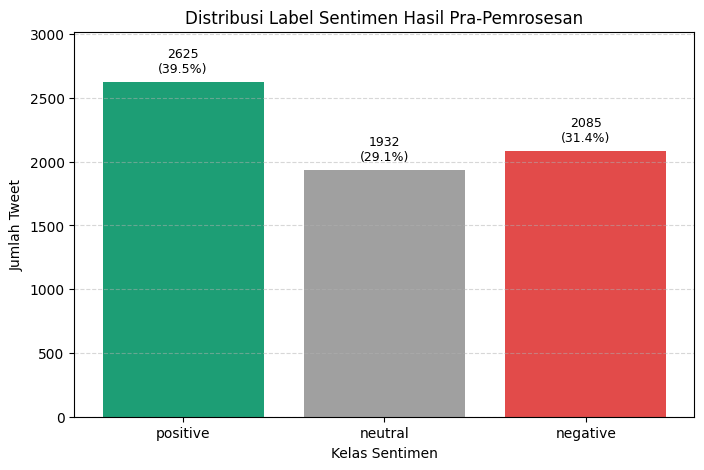

In [72]:
# =========================
# 5. Visualisasi Distribusi Sentimen
# =========================
if 'label' not in df.columns:
    raise ValueError("❌ Kolom 'label' tidak ditemukan")

# Cleaning Label
df['label'] = df['label'].astype(str).str.strip().str.lower()
valid_labels = ['positive', 'neutral', 'negative']
df_sentimen = df[df['label'].isin(valid_labels)]

# Hitung Distribusi
order = ['positive', 'neutral', 'negative']
label_counts = df_sentimen['label'].value_counts().reindex(order, fill_value=0)
total = label_counts.sum()

# Color Mapping
color_map = {
    'positive': '#1D9E75',
    'negative': '#E24B4A',
    'neutral' : '#A0A0A0'
}
colors = [color_map[label] for label in label_counts.index]

# =========================
# Plot
# =========================
plt.figure(figsize=(8, 5))

bars = plt.bar(
    label_counts.index,
    label_counts.values,
    color=colors
)

# Judul & Label
plt.title("Distribusi Label Sentimen Hasil Pra-Pemrosesan", fontsize=12)
plt.xlabel("Kelas Sentimen", fontsize=10)
plt.ylabel("Jumlah Tweet", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# =========================
# Annotation
# =========================
offset = max(label_counts.values) * 0.02

for bar in bars:
    height = bar.get_height()

    if height > 0:
        percentage = (height / total) * 100

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{int(height)}\n({percentage:.1f}%)",
            ha='center',
            va='bottom',
            fontsize=9
        )

# =========================
# TAMBAH SPACE ATAS
# =========================
max_height = max(label_counts.values)
plt.ylim(0, max_height * 1.15)  # tambah 15% ruang atas

# =========================
# Save
# =========================
fig = plt.gcf()

fig.savefig(
    output_path_sentimen,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

print(f"\n💾 Chart Sentimen berhasil disimpan di:\n{output_path_sentimen}")
plt.show()


📊 Summary Distribusi Kata Kunci:
Total Data (Valid Keyword): 6642
- MBG                  : 3471 (52.3%)
- Makan Bergizi Gratis : 3171 (47.7%)

💾 Pie Chart Keyword berhasil disimpan di:
/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_keyword.png


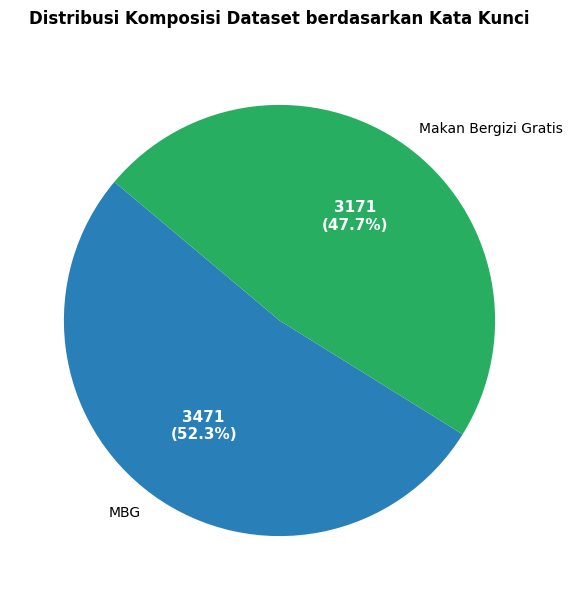

In [73]:
# =========================
# 6. Visualisasi Komposisi Keyword (Pie Chart)
# =========================
if 'source_keyword' in df.columns:
    valid_keywords = ['mbg', 'makan_bergizi_gratis']
    df_keyword = df[df['source_keyword'].astype(str).str.lower().isin(valid_keywords)].copy()

    keyword_map = {
        'mbg': 'MBG',
        'makan_bergizi_gratis': 'Makan Bergizi Gratis'
    }
    df_keyword['keyword_label'] = df_keyword['source_keyword'].astype(str).str.lower().map(keyword_map)
    keyword_counts = df_keyword['keyword_label'].value_counts()

    # --- Psikologi Warna ---
    # Makan Bergizi Gratis: Hijau (Kesehatan/Nutrisi)
    # MBG: Biru (Kepercayaan/Instansi)
    color_dict = {'Makan Bergizi Gratis': '#27ae60', 'MBG': '#2980b9'}
    pie_colors = [color_dict[label] for label in keyword_counts.index]

    # Fungsi custom untuk menampilkan <total_data>\n(<presentase>) di dalam chart
    def func_label(pct, allvals):
        absolute = int(round(pct/100.*sum(allvals)))
        return f"{absolute:d}\n({pct:.1f}%)"

    plt.figure(figsize=(8, 7))

    # Membuat Pie Chart
    wedges, texts, autotexts = plt.pie(
        keyword_counts.values,
        labels=keyword_counts.index,      # Label kategori di samping chart
        autopct=lambda pct: func_label(pct, keyword_counts.values), # Label data di dalam chart
        startangle=140,
        colors=pie_colors,
        labeldistance=1.1,               # Jarak label kategori samping (sedikit di luar)
        textprops={'fontsize': 10, 'fontweight': 'normal'}
    )

    # Mengatur style teks di dalam chart agar lebih terbaca (Putih & Bold)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
        autotext.set_fontsize(11)

    # Judul Chart
    plt.title("Distribusi Komposisi Dataset berdasarkan Kata Kunci", fontsize=12, pad=20, fontweight='bold')

    # Menyimpan Grafik
    fig = plt.gcf()
    fig.savefig(
        output_path_keyword,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    # =========================
    # Data Summary Output
    # =========================
    total_data = keyword_counts.sum()
    count_mbg = keyword_counts.get('MBG', 0)
    count_mbg_gratis = keyword_counts.get('Makan Bergizi Gratis', 0)

    pct_mbg = (count_mbg / total_data) * 100 if total_data > 0 else 0
    pct_mbg_gratis = (count_mbg_gratis / total_data) * 100 if total_data > 0 else 0

    print("\n📊 Summary Distribusi Kata Kunci:")
    print(f"Total Data (Valid Keyword): {total_data}")
    print(f"- MBG                  : {count_mbg} ({pct_mbg:.1f}%)")
    print(f"- Makan Bergizi Gratis : {count_mbg_gratis} ({pct_mbg_gratis:.1f}%)")

    print(f"\n💾 Pie Chart Keyword berhasil disimpan di:\n{output_path_keyword}")
    plt.show()
else:
    print("❌ Kolom 'source_keyword' tidak ditemukan.")

📊 RAW DATA (full_text)


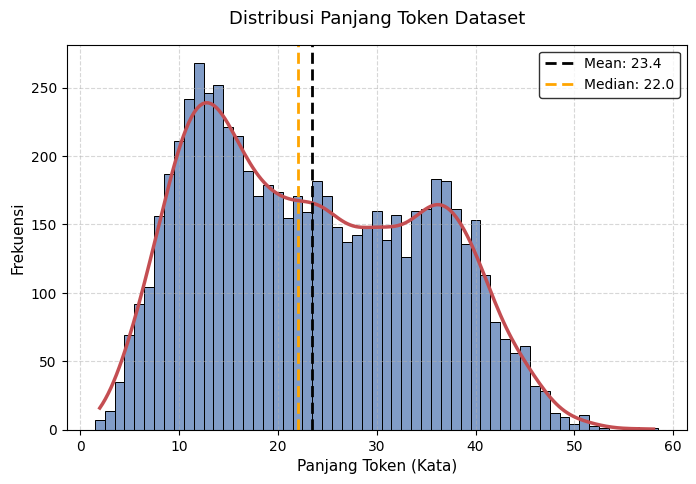

📊 CLEAN DATA (text_bert)


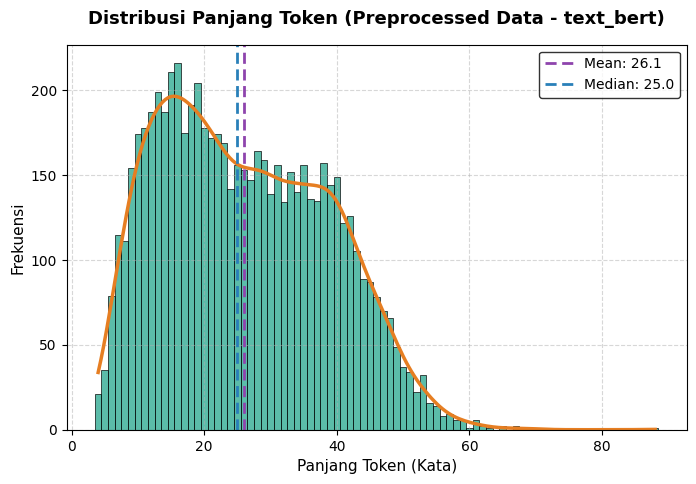


💾 Chart Raw Data berhasil disimpan di:
   /content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_token_raw.png
💾 Chart Clean Data berhasil disimpan di:
   /content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_token_clean.png

📊 SUMMARY STATISTIK KOMPARASI PANJANG TOKEN
Total Baris Data (Tweet) : 6,642 tweet
---------------------------------------------------------
🔹 1. RAW DATA (full_text)
   Total Keseluruhan Kata   : 155,727 tokens
   Rata-rata (Mean)         : 23.4 kata per tweet
   Nilai Tengah (Median)    : 22.0 kata
   Token Terpendek (Min)    : 2 kata
   Token Terpanjang (Max)   : 58 kata
   Modus (Paling Sering)    : 12 kata (muncul di 268 tweet)

🔸 2. PREPROCESSED DATA (text_bert)
   Total Keseluruhan Kata   : 173,089 tokens
   Rata-rata (Mean)         : 26.1 kata per tweet
   Nilai Tengah (Median)    : 25.0 kata
   Token Terpendek (Min)    : 4 kata
   Token Terpanjang (Max)   : 88 kata
   Modus (Paling Sering) 

In [74]:
# ==========================================
# 7. Visualisasi & Komparasi Distribusi Panjang Token
# (Raw Data vs Preprocessed Data)
# ==========================================
# Pastikan kedua kolom ada
if 'full_text' in df.columns and 'text_bert' in df.columns:

    # ---------------------------------------------------------
    # A. PERHITUNGAN PANJANG TOKEN
    # ---------------------------------------------------------
    # Raw Data
    df['token_length_raw'] = df['full_text'].astype(str).apply(lambda x: len(x.split()))
    # Clean Data (Data siap masuk model BERT)
    df['token_length_clean'] = df['text_bert'].astype(str).apply(lambda x: len(x.split()))

    # Fungsi bantuan untuk menghitung statistik
    def get_stats(column_name):
        return {
            'mean': df[column_name].mean(),
            'median': df[column_name].median(),
            'min': df[column_name].min(),
            'max': df[column_name].max(),
            'mode': df[column_name].mode()[0],
            'mode_freq': (df[column_name] == df[column_name].mode()[0]).sum(),
            'total_tokens': df[column_name].sum(),
            'total_tweets': len(df)
        }

    stats_raw = get_stats('token_length_raw')
    stats_clean = get_stats('token_length_clean')

    # ---------------------------------------------------------
    # B. PLOT 1: RAW DATA (full_text)
    # ---------------------------------------------------------
    print("=========================================================")
    print("📊 RAW DATA (full_text)")
    print("=========================================================")
    plt.figure(figsize=(8, 5))

    ax1 = sns.histplot(df['token_length_raw'], kde=True, color='#4C72B0', alpha=0.7, discrete=True)
    if ax1.lines:
        ax1.lines[0].set_color('#C44E52')
        ax1.lines[0].set_linewidth(2.5)

    plt.axvline(stats_raw['mean'], color='black', linestyle=(0, (4, 2)), linewidth=2, label=f"Mean: {stats_raw['mean']:.1f}")
    plt.axvline(stats_raw['median'], color='#FFA500', linestyle=(0, (4, 2)), linewidth=2, label=f"Median: {stats_raw['median']:.1f}")

    plt.title("Distribusi Panjang Token Dataset", fontsize=13, pad=15)
    plt.xlabel("Panjang Token (Kata)", fontsize=11)
    plt.ylabel("Frekuensi", fontsize=11)

    plt.grid(axis='both', linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', fontsize=10, frameon=True, edgecolor='black')

    fig1 = plt.gcf()
    fig1.savefig(output_path_token_raw, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    # ---------------------------------------------------------
    # C. PLOT 2: CLEAN DATA (text_bert)
    # ---------------------------------------------------------
    print("=========================================================")
    print("📊 CLEAN DATA (text_bert)")
    print("=========================================================")
    plt.figure(figsize=(8, 5))

    # Warna Teal (#16a085) melambangkan data yang sudah dibersihkan, kurva Orange (#e67e22)
    ax2 = sns.histplot(df['token_length_clean'], kde=True, color='#16a085', alpha=0.7, discrete=True)
    if ax2.lines:
        ax2.lines[0].set_color('#e67e22')
        ax2.lines[0].set_linewidth(2.5)

    # Garis Mean (Ungu gelap) & Median (Biru gelap) agar kontras dengan Teal
    plt.axvline(stats_clean['mean'], color='#8e44ad', linestyle=(0, (4, 2)), linewidth=2, label=f"Mean: {stats_clean['mean']:.1f}")
    plt.axvline(stats_clean['median'], color='#2980b9', linestyle=(0, (4, 2)), linewidth=2, label=f"Median: {stats_clean['median']:.1f}")

    plt.title("Distribusi Panjang Token (Preprocessed Data - text_bert)", fontsize=13, pad=15, fontweight='bold')
    plt.xlabel("Panjang Token (Kata)", fontsize=11)
    plt.ylabel("Frekuensi", fontsize=11)

    plt.grid(axis='both', linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', fontsize=10, frameon=True, edgecolor='black')

    fig2 = plt.gcf()
    fig2.savefig(output_path_token_clean, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    # ---------------------------------------------------------
    # D. DATA SUMMARY OUTPUT
    # ---------------------------------------------------------
    print("\n💾 Chart Raw Data berhasil disimpan di:")
    print(f"   {output_path_token_raw}")
    print("💾 Chart Clean Data berhasil disimpan di:")
    print(f"   {output_path_token_clean}\n")

    print("=========================================================")
    print("📊 SUMMARY STATISTIK KOMPARASI PANJANG TOKEN")
    print("=========================================================")
    print(f"Total Baris Data (Tweet) : {stats_raw['total_tweets']:,} tweet")
    print("---------------------------------------------------------")

    print("🔹 1. RAW DATA (full_text)")
    print(f"   Total Keseluruhan Kata   : {stats_raw['total_tokens']:,} tokens")
    print(f"   Rata-rata (Mean)         : {stats_raw['mean']:.1f} kata per tweet")
    print(f"   Nilai Tengah (Median)    : {stats_raw['median']:.1f} kata")
    print(f"   Token Terpendek (Min)    : {stats_raw['min']} kata")
    print(f"   Token Terpanjang (Max)   : {stats_raw['max']} kata")
    print(f"   Modus (Paling Sering)    : {stats_raw['mode']} kata (muncul di {stats_raw['mode_freq']} tweet)")
    print("")

    print("🔸 2. PREPROCESSED DATA (text_bert)")
    print(f"   Total Keseluruhan Kata   : {stats_clean['total_tokens']:,} tokens")
    print(f"   Rata-rata (Mean)         : {stats_clean['mean']:.1f} kata per tweet")
    print(f"   Nilai Tengah (Median)    : {stats_clean['median']:.1f} kata")
    print(f"   Token Terpendek (Min)    : {stats_clean['min']} kata")
    print(f"   Token Terpanjang (Max)   : {stats_clean['max']} kata")
    print(f"   Modus (Paling Sering)    : {stats_clean['mode']} kata (muncul di {stats_clean['mode_freq']} tweet)")

    # Hitung selisih reduksi kata
    reduced_words = stats_raw['total_tokens'] - stats_clean['total_tokens']
    reduced_pct = (reduced_words / stats_raw['total_tokens']) * 100 if stats_raw['total_tokens'] > 0 else 0
    print("---------------------------------------------------------")
    print(f"📉 Total kata yang direduksi/dibersihkan : {reduced_words:,} tokens ({reduced_pct:.1f}%)")
    print("=========================================================\n")

else:
    print("❌ Kolom 'full_text' atau 'text_bert' tidak ditemukan. Pastikan nama kolom benar di dataset.")


💾 Grouped Bar Chart berhasil disimpan di:
/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_grouped_sentimen_keyword.png


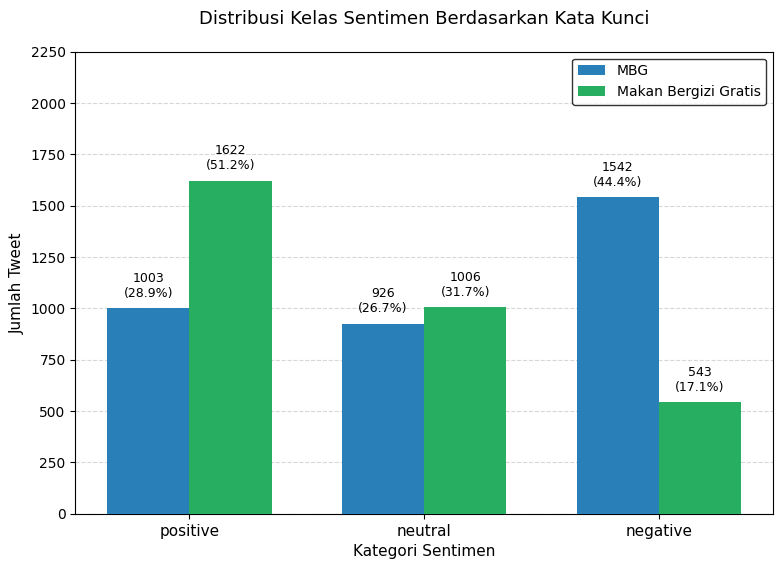


📊 SUMMARY DISTRIBUSI SENTIMEN PER KEYWORD
🔸 Kata Kunci: MBG (Total: 3471)
   - Positive   :  1003 tweet (28.9%)
   - Neutral    :   926 tweet (26.7%)
   - Negative   :  1542 tweet (44.4%)

🔸 Kata Kunci: Makan Bergizi Gratis (Total: 3171)
   - Positive   :  1622 tweet (51.2%)
   - Neutral    :  1006 tweet (31.7%)
   - Negative   :   543 tweet (17.1%)



In [75]:
# ==========================================
# 8. Visualisasi Distribusi Sentimen per Kata Kunci
# (Grouped Bar Chart - Standard Research Style)
# ==========================================
if 'source_keyword' in df.columns and 'label' in df.columns:
    # 1. Persiapan dan Pembersihan Data
    valid_labels = ['positive', 'neutral', 'negative']
    df_valid = df[df['label'].astype(str).str.strip().str.lower().isin(valid_labels)].copy()

    # Standarisasi teks label menjadi huruf kecil (lowercase)
    df_valid['label'] = df_valid['label'].astype(str).str.strip().str.lower()
    df_valid['clean_keyword'] = df_valid['source_keyword'].astype(str).str.strip().str.lower()

    # Array sentimen dalam bentuk lowercase
    sentiments = ['positive', 'neutral', 'negative']

    # 2. Menghitung Data Agregat
    # Hitung distribusi khusus kata kunci "mbg"
    mbg_counts = df_valid[df_valid['clean_keyword'] == 'mbg']['label'].value_counts().reindex(sentiments, fill_value=0)
    total_mbg = mbg_counts.sum()

    # Hitung distribusi khusus kata kunci "makan_bergizi_gratis"
    mbg_gratis_counts = df_valid[df_valid['clean_keyword'] == 'makan_bergizi_gratis']['label'].value_counts().reindex(sentiments, fill_value=0)
    total_mbg_gratis = mbg_gratis_counts.sum()

    # 3. Setup Layout Figure
    x = np.arange(len(sentiments))  # Titik sumbu X untuk sentimen
    width = 0.35                    # Lebar tiap bar

    plt.figure(figsize=(9, 6))

    # 4. Plotting Grouped Bars (TIDAK ADA BORDER PADA BATANG)
    # Tanpa parameter edgecolor agar batang bersih dari garis tepi
    bar1 = plt.bar(x - width/2, mbg_counts.values, width, label='MBG', color='#2980b9', zorder=3)
    bar2 = plt.bar(x + width/2, mbg_gratis_counts.values, width, label='Makan Bergizi Gratis', color='#27ae60', zorder=3)

    # 5. Styling & Label
    plt.title("Distribusi Kelas Sentimen Berdasarkan Kata Kunci", fontsize=13, pad=20)
    plt.xlabel("Kategori Sentimen", fontsize=11)
    plt.ylabel("Jumlah Tweet", fontsize=11)

    # Menampilkan label X dengan format lowercase
    plt.xticks(x, sentiments, fontsize=11)

    # Grid horizontal (Border bingkai chart utama otomatis tetap tampil)
    plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

    # 6. Anotasi Angka dan Persentase
    max_val = max(max(mbg_counts.values), max(mbg_gratis_counts.values))
    offset = max_val * 0.025

    def add_labels(bars, total_subgroup):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                pct = (height / total_subgroup) * 100 if total_subgroup > 0 else 0
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + offset,
                    f"{int(height)}\n({pct:.1f}%)",
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

    # Memanggil anotasi
    add_labels(bar1, total_mbg)
    add_labels(bar2, total_mbg_gratis)

    # ==========================================
    # MENAMBAH SPACE ATAS SECARA EKSPLISIT
    # ==========================================
    y_limit = max(2250, max_val * 1.25)
    plt.ylim(0, y_limit)

    # Legend normal (tidak bold) dan menggunakan kotak border agar rapi
    plt.legend(loc='upper right', fontsize=10, frameon=True, edgecolor='black')

    # 7. Menyimpan Output Chart
    fig = plt.gcf()
    fig.savefig(output_grouped_path, dpi=300, bbox_inches='tight', facecolor='white')

    # ==========================================
    # 8. DATA SUMMARY OUTPUT
    # ==========================================
    print(f"\n💾 Grouped Bar Chart berhasil disimpan di:\n{output_grouped_path}")
    plt.show() # Tampilkan chart terlebih dahulu

    # Tampilkan summary persentase dalam bentuk teks
    print("\n=============================================")
    print("📊 SUMMARY DISTRIBUSI SENTIMEN PER KEYWORD")
    print("=============================================")

    print(f"🔸 Kata Kunci: MBG (Total: {total_mbg})")
    for sent in sentiments:
        count = mbg_counts.get(sent, 0)
        pct = (count / total_mbg) * 100 if total_mbg > 0 else 0
        print(f"   - {sent.capitalize():<10} : {count:>5} tweet ({pct:.1f}%)")

    print(f"\n🔸 Kata Kunci: Makan Bergizi Gratis (Total: {total_mbg_gratis})")
    for sent in sentiments:
        count = mbg_gratis_counts.get(sent, 0)
        pct = (count / total_mbg_gratis) * 100 if total_mbg_gratis > 0 else 0
        print(f"   - {sent.capitalize():<10} : {count:>5} tweet ({pct:.1f}%)")
    print("=============================================\n")

else:
    print("❌ Kolom 'source_keyword' atau 'label' tidak ditemukan di dataset.")